In [3]:
class Embedding:
    def __init__(self, w):
        self.params = [w]
        self.grads = [np.zeros_like(w)]
        self.idx = None
    
    def forward(self, idx):
        w, = self.params
        self.idx = idx
        out = w[idx]
        return out
    
    def backward(self, dout):
        dw, = self.grads
        dw[...] = 0
        
        for i, word_id in enumerate(self.idx):
            dw[word_id]  += dout[i]
        
        return None

In [4]:
class EmbeddingDot:
    def __init__(self, w):
        self.embed = Embedding(w)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None
        
    def forward(self, h, idx):
        target_w = self.embed.forward(idx)
        out = np.sum(target_w * h, axis=1)
        
        self.cache = (h, target_w)
        return out
    
    def backward(self, dout):
        h, target_w = self.cache
        dout = dout.reshape(dout.shape[0], 1)
        
        dtarget_w = dout * h
        self.embed.backward(dtarget_w)
        dh = dout * target_w
        return dh

In [5]:
import numpy as np

np.random.choice(10)

0

In [6]:
np.random.choice(10)

2

In [7]:
p = [0.7, 0.29, 0.01]
new_p = np.power(p, 0.75)
new_p /= np.sum(new_p)
print(new_p)

[0.64196878 0.33150408 0.02652714]


In [8]:
from negative_sampling_layer import UnigramSampler

corpus = np.array([0,1,2,3,4,1,2,3])
power = 0.75
sample_size = 2

sampler = UnigramSampler(corpus, power, sample_size)
target = np.array([1,3,0])
negative_sample = sampler.get_negative_sample(target)
print(negative_sample)

[[3 0]
 [0 4]
 [3 1]]


In [9]:
class NegativeSamplingLoss:
    def __init__(self, w, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(w) for _ in range(sample_size + 1)]
        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads
            
    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)
        
        # 긍정적 예 순전파
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)
        
        # 부정적 예 순전파
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)
            
        return loss
    
    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = lo.backward(dout)
            dh += l1.backward(dscore)
            
        return dh

In [11]:
from common.layers import Embedding
from negative_sampling_layer import NegativeSamplingLoss

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        v, h = vocab_size, hidden_size
        
        # 가중치 초기화
        w_in = 0.01 * np.random.randn(v, h).astype('f')
        w_out = 0.01 * np.random.randn(h, v).astype('f')
        
        # 계층 생성
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(w_in)
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(w_out, corpus, power=0.75, sample_size=5)
        
        # 모든 가중치와 기울기를 배열에 모은다
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads
            
        # 인스턴스 변수에 단어의 분산 표현을 저장한다
        self.word_vecs = w_in
        
    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss
    
    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None

| 에폭 1 |  반복 1 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 21 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 41 / 9295 | 시간 1[s] | 손실 4.15
| 에폭 1 |  반복 61 / 9295 | 시간 1[s] | 손실 4.12
| 에폭 1 |  반복 81 / 9295 | 시간 1[s] | 손실 4.05
| 에폭 1 |  반복 101 / 9295 | 시간 2[s] | 손실 3.92
| 에폭 1 |  반복 121 / 9295 | 시간 2[s] | 손실 3.77
| 에폭 1 |  반복 141 / 9295 | 시간 2[s] | 손실 3.62
| 에폭 1 |  반복 161 / 9295 | 시간 3[s] | 손실 3.49
| 에폭 1 |  반복 181 / 9295 | 시간 3[s] | 손실 3.36
| 에폭 1 |  반복 201 / 9295 | 시간 4[s] | 손실 3.24
| 에폭 1 |  반복 221 / 9295 | 시간 4[s] | 손실 3.16
| 에폭 1 |  반복 241 / 9295 | 시간 4[s] | 손실 3.10
| 에폭 1 |  반복 261 / 9295 | 시간 5[s] | 손실 3.03
| 에폭 1 |  반복 281 / 9295 | 시간 5[s] | 손실 2.97
| 에폭 1 |  반복 301 / 9295 | 시간 5[s] | 손실 2.94
| 에폭 1 |  반복 321 / 9295 | 시간 6[s] | 손실 2.88
| 에폭 1 |  반복 341 / 9295 | 시간 6[s] | 손실 2.86
| 에폭 1 |  반복 361 / 9295 | 시간 7[s] | 손실 2.84
| 에폭 1 |  반복 381 / 9295 | 시간 7[s] | 손실 2.80
| 에폭 1 |  반복 401 / 9295 | 시간 7[s] | 손실 2.77
| 에폭 1 |  반복 421 / 9295 | 시간 8[s] | 손실 2.77
| 에폭 1 |  반복 441 / 9295 | 시간 8[s] | 손실

| 에폭 1 |  반복 3601 / 9295 | 시간 73[s] | 손실 2.43
| 에폭 1 |  반복 3621 / 9295 | 시간 74[s] | 손실 2.45
| 에폭 1 |  반복 3641 / 9295 | 시간 74[s] | 손실 2.43
| 에폭 1 |  반복 3661 / 9295 | 시간 74[s] | 손실 2.41
| 에폭 1 |  반복 3681 / 9295 | 시간 75[s] | 손실 2.43
| 에폭 1 |  반복 3701 / 9295 | 시간 75[s] | 손실 2.45
| 에폭 1 |  반복 3721 / 9295 | 시간 76[s] | 손실 2.45
| 에폭 1 |  반복 3741 / 9295 | 시간 76[s] | 손실 2.44
| 에폭 1 |  반복 3761 / 9295 | 시간 76[s] | 손실 2.42
| 에폭 1 |  반복 3781 / 9295 | 시간 77[s] | 손실 2.44
| 에폭 1 |  반복 3801 / 9295 | 시간 77[s] | 손실 2.41
| 에폭 1 |  반복 3821 / 9295 | 시간 78[s] | 손실 2.42
| 에폭 1 |  반복 3841 / 9295 | 시간 78[s] | 손실 2.42
| 에폭 1 |  반복 3861 / 9295 | 시간 79[s] | 손실 2.41
| 에폭 1 |  반복 3881 / 9295 | 시간 79[s] | 손실 2.42
| 에폭 1 |  반복 3901 / 9295 | 시간 79[s] | 손실 2.41
| 에폭 1 |  반복 3921 / 9295 | 시간 80[s] | 손실 2.45
| 에폭 1 |  반복 3941 / 9295 | 시간 80[s] | 손실 2.39
| 에폭 1 |  반복 3961 / 9295 | 시간 81[s] | 손실 2.41
| 에폭 1 |  반복 3981 / 9295 | 시간 81[s] | 손실 2.44
| 에폭 1 |  반복 4001 / 9295 | 시간 81[s] | 손실 2.43
| 에폭 1 |  반복 4021 / 9295 | 시간 82[s

| 에폭 1 |  반복 7121 / 9295 | 시간 146[s] | 손실 2.31
| 에폭 1 |  반복 7141 / 9295 | 시간 147[s] | 손실 2.29
| 에폭 1 |  반복 7161 / 9295 | 시간 147[s] | 손실 2.31
| 에폭 1 |  반복 7181 / 9295 | 시간 147[s] | 손실 2.26
| 에폭 1 |  반복 7201 / 9295 | 시간 148[s] | 손실 2.30
| 에폭 1 |  반복 7221 / 9295 | 시간 148[s] | 손실 2.30
| 에폭 1 |  반복 7241 / 9295 | 시간 149[s] | 손실 2.31
| 에폭 1 |  반복 7261 / 9295 | 시간 149[s] | 손실 2.29
| 에폭 1 |  반복 7281 / 9295 | 시간 149[s] | 손실 2.27
| 에폭 1 |  반복 7301 / 9295 | 시간 150[s] | 손실 2.31
| 에폭 1 |  반복 7321 / 9295 | 시간 150[s] | 손실 2.32
| 에폭 1 |  반복 7341 / 9295 | 시간 151[s] | 손실 2.29
| 에폭 1 |  반복 7361 / 9295 | 시간 151[s] | 손실 2.27
| 에폭 1 |  반복 7381 / 9295 | 시간 151[s] | 손실 2.26
| 에폭 1 |  반복 7401 / 9295 | 시간 152[s] | 손실 2.30
| 에폭 1 |  반복 7421 / 9295 | 시간 152[s] | 손실 2.31
| 에폭 1 |  반복 7441 / 9295 | 시간 153[s] | 손실 2.29
| 에폭 1 |  반복 7461 / 9295 | 시간 153[s] | 손실 2.30
| 에폭 1 |  반복 7481 / 9295 | 시간 154[s] | 손실 2.29
| 에폭 1 |  반복 7501 / 9295 | 시간 154[s] | 손실 2.27
| 에폭 1 |  반복 7521 / 9295 | 시간 154[s] | 손실 2.29
| 에폭 1 |  반복 

C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


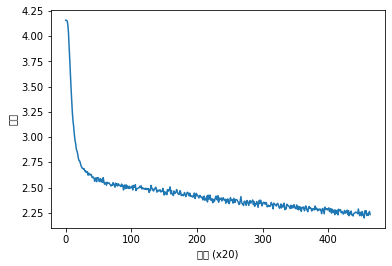

NameError: name 'np' is not defined

In [5]:
import sys
sys.path.append('..')
from common import config
config.GPU = True
import pickle
import numpy as np
from common.trainer import Trainer
from common.optimizer import Adam
from cbow import CBOW
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb

# 하이퍼파라미터 설정
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 1

# 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)
    
# 모델 등 생성
model = CBOW(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 학습 시작
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 나중에 사용할 수 있도록 필요한 데이터 저장
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

In [1]:
import sys
sys.path.append('..')
from common.util import most_similar
import pickle

pkl_file = 'cbow_params.pkl'

with open(pkl_file, 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']
    
querys = ['you', 'year', 'car','toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


[query] you
 we: 0.6103515625
 someone: 0.59130859375
 i: 0.55419921875
 something: 0.48974609375
 anyone: 0.47314453125

[query] year
 month: 0.71875
 week: 0.65234375
 spring: 0.62744140625
 summer: 0.6259765625
 decade: 0.603515625

[query] car
 luxury: 0.497314453125
 arabia: 0.47802734375
 auto: 0.47119140625
 disk-drive: 0.450927734375
 travel: 0.4091796875

[query] toyota
 ford: 0.55078125
 instrumentation: 0.509765625
 mazda: 0.49365234375
 bethlehem: 0.47509765625
 nissan: 0.474853515625
